In [23]:
import pandas as pd

df = pd.read_csv("Nat_Gas (1).csv")
df['Dates'] = pd.to_datetime(df['Dates'], format='%m/%d/%y')
df = df.sort_values('Dates').reset_index(drop=True)

print(df.head())
print(df.dtypes)

       Dates  Prices
0 2020-10-31    10.1
1 2020-11-30    10.3
2 2020-12-31    11.0
3 2021-01-31    10.9
4 2021-02-28    10.9
Dates     datetime64[ns]
Prices           float64
dtype: object


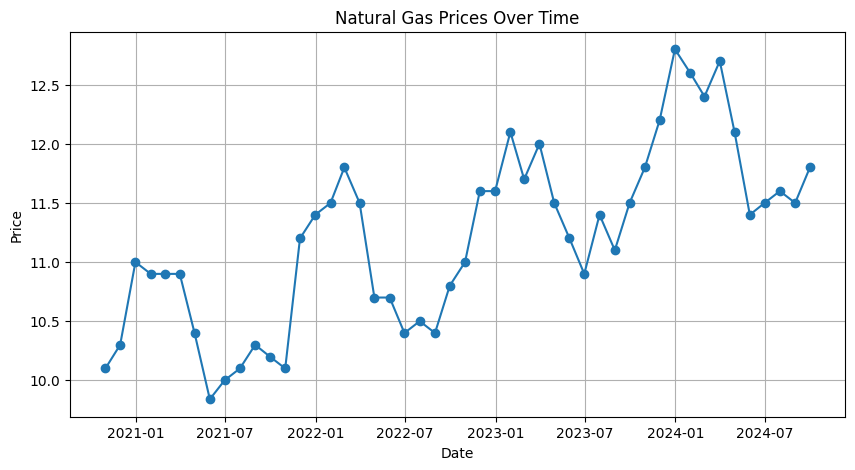

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(df['Dates'], df['Prices'], marker='o')
plt.title("Natural Gas Prices Over Time")
plt.xlabel("Date")
plt.ylabel("Price")
plt.grid(True)
plt.show()

In [25]:
start_date = df['Dates'].min()
df['months_since_start'] = df['Dates'].apply(
    lambda d: (d.year - start_date.year) * 12 + (d.month - start_date.month)
)

print(df.head())

       Dates  Prices  months_since_start
0 2020-10-31    10.1                   0
1 2020-11-30    10.3                   1
2 2020-12-31    11.0                   2
3 2021-01-31    10.9                   3
4 2021-02-28    10.9                   4


In [26]:
import numpy as np

t = df['months_since_start'].values
X = np.column_stack([
    t,                                  # linear trend
    np.sin(2 * np.pi * t / 12),        # seasonal component (yearly cycle)
    np.cos(2 * np.pi * t / 12),
    np.ones(len(t))                     # intercept
])
y = df['Prices'].values

print(X.shape, y.shape)

(48, 4) (48,)


In [27]:
coeffs, *_ = np.linalg.lstsq(X, y, rcond=None)
a_trend, b_sin, c_cos, intercept = coeffs

print("Trend coefficient:", a_trend)
print("Sin coefficient:", b_sin)
print("Cos coefficient:", c_cos)
print("Intercept:", intercept)

Trend coefficient: 0.04562417223125899
Sin coefficient: 0.6900713341696303
Cos coefficient: -0.037886505202992304
Intercept: 10.134915285898746


In [28]:
import pandas as pd

def months_from_start(date):
    return (date.year - start_date.year) * 12 + (date.month - start_date.month) \
           + (date.day - start_date.day) / 30.44

def price_estimate(date_input):
    date = pd.to_datetime(date_input)
    t_query = months_from_start(date)

    max_extrapolation = df['months_since_start'].max() + 12
    if t_query < 0 or t_query > max_extrapolation:
        raise ValueError("Date is outside the supported range.")

    price = (a_trend * t_query
             + b_sin * np.sin(2 * np.pi * t_query / 12)
             + c_cos * np.cos(2 * np.pi * t_query / 12)
             + intercept)
    return round(price, 2)

In [29]:
print(price_estimate("2023-06-15"))   # interpolation test
print(price_estimate("2025-03-31"))   # extrapolation test

11.12
12.93


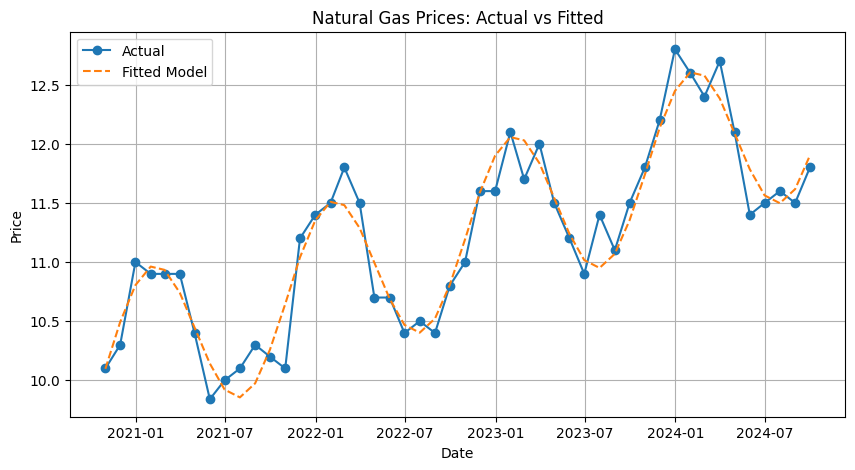

In [30]:
fitted_prices = (a_trend * t
                  + b_sin * np.sin(2 * np.pi * t / 12)
                  + c_cos * np.cos(2 * np.pi * t / 12)
                  + intercept)

plt.figure(figsize=(10,5))
plt.plot(df['Dates'], df['Prices'], marker='o', label='Actual')
plt.plot(df['Dates'], fitted_prices, linestyle='--', label='Fitted Model')
plt.title("Natural Gas Prices: Actual vs Fitted")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid(True)
plt.show()

In [31]:
def price_contract(injection_dates, withdrawal_dates, injection_prices, withdrawal_prices,
                    injection_rate, withdrawal_rate, max_storage_volume, storage_cost_per_month):
    pass  # we'll fill this in

In [32]:
def price_contract(injection_dates, withdrawal_dates, injection_prices, withdrawal_prices,
                    injection_rate, withdrawal_rate, max_storage_volume, storage_cost_per_month):

    current_volume = 0
    cash_flows = 0

    # Combine all events (injections = negative cash flow, withdrawals = positive), sorted by date
    events = []
    for date, price in zip(injection_dates, injection_prices):
        events.append((date, 'inject', price))
    for date, price in zip(withdrawal_dates, withdrawal_prices):
        events.append((date, 'withdraw', price))
    events.sort(key=lambda x: x[0])

    return events  # temporary, just to check ordering

In [33]:
def price_contract(injection_dates, withdrawal_dates, injection_prices, withdrawal_prices,
                    injection_rate, withdrawal_rate, max_storage_volume, storage_cost_per_month,
                    injection_withdrawal_cost_rate=0):

    current_volume = 0
    cash_flows = 0

    events = []
    for date, price in zip(injection_dates, injection_prices):
        events.append((date, 'inject', price))
    for date, price in zip(withdrawal_dates, withdrawal_prices):
        events.append((date, 'withdraw', price))
    events.sort(key=lambda x: x[0])

    last_date = events[0][0]

    for date, action, price in events:
        months_elapsed = (date - last_date).days / 30.44
        if current_volume > 0:
            storage_cost = storage_cost_per_month * months_elapsed
            cash_flows -= storage_cost

        if action == 'inject':
            volume_moved = min(injection_rate, max_storage_volume - current_volume)
            current_volume += volume_moved
            cash_flows -= volume_moved * price
            cash_flows -= volume_moved * injection_withdrawal_cost_rate
        elif action == 'withdraw':
            volume_moved = min(withdrawal_rate, current_volume)
            current_volume -= volume_moved
            cash_flows += volume_moved * price
            cash_flows -= volume_moved * injection_withdrawal_cost_rate

        last_date = date

    return cash_flows
    print(price_contract(in_dates, out_dates, in_prices, out_prices, 100000, 100000, 500000, 100000, injection_withdrawal_cost_rate=0.01))

In [34]:
result = price_contract(in_dates, out_dates, in_prices, out_prices, 100000, 100000, 500000, 100000, injection_withdrawal_cost_rate=0.01)
print("done")
print(result)

done
-456467.8055190537


In [35]:
in_dates = [pd.Timestamp("2024-06-30"), pd.Timestamp("2024-07-31")]
out_dates = [pd.Timestamp("2024-12-31"), pd.Timestamp("2025-01-31")]
in_prices = [price_estimate("2024-06-30"), price_estimate("2024-07-31")]
out_prices = [price_estimate("2024-12-31"), price_estimate("2025-01-31")]

result = price_contract(in_dates, out_dates, in_prices, out_prices,
                         injection_rate=50000, withdrawal_rate=50000,
                         max_storage_volume=100000, storage_cost_per_month=100000,
                         injection_withdrawal_cost_rate=0.01)
print(result)

-554807.4901445466
